In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [2]:
# Custom loader function for .npy files
def mat_loader(path):
    """Load .npy file and convert to tensor"""
    image = sio.loadmat(path)['complex_img']  # Assuming the .mat file has a 'data' variable
    
    image = torch.from_numpy(image)

    # Add channel dimension but keep as numpy
    if image.ndim == 2:
        image = image.unsqueeze(0)  # (H, W) -> (1, H, W)

    # Convert single channel to 3-channel for ResNet (expects RGB)
    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)  # (1, H, W) -> (3, H, W)
    
    return image  # (H, W) -> (3, H, W)

# Before Pre-processing

In [3]:
synth_ds = datasets.DatasetFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/mat_files/synth",
    extensions = (".mat"),
    loader = mat_loader,
)
meas_ds = datasets.DatasetFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/mat_files/real",
    extensions = (".mat"),
    loader = mat_loader,
)

In [8]:
synth_vals = []

for i in range(len(synth_ds)):
    synth_img = np.absolute(synth_ds[i][0][0])
    u, sigma = synth_img.mean(), synth_img.var()
    synth_vals.append((u.item(), sigma.item()))

meas_vals = []

for i in range(len(meas_ds)):
    meas_img = np.absolute(meas_ds[i][0][0])
    u, sigma = meas_img.mean(), meas_img.var()
    meas_vals.append((u.item(), sigma.item()))

/tmp/ipykernel_613193/1281792277.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  synth_img = np.absolute(synth_ds[i][0][0])
/tmp/ipykernel_613193/1281792277.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  meas_img = np.absolute(meas_ds[i][0][0])


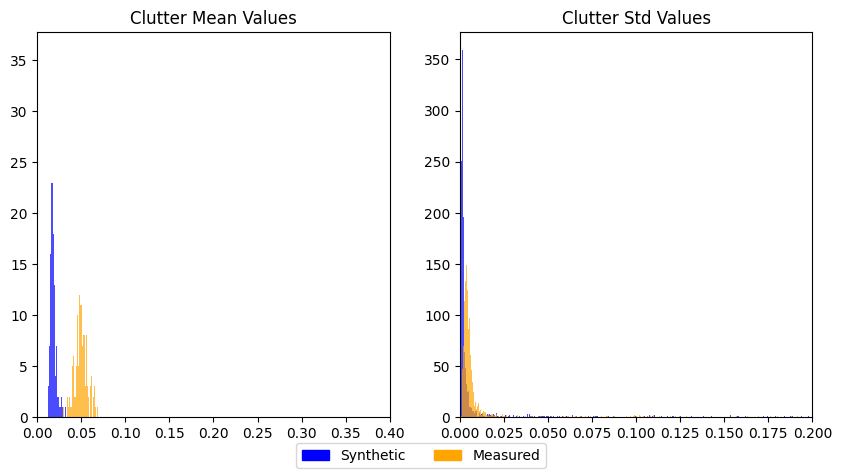

In [10]:
fig = plt.figure(figsize=(10, 5))

color_lst = ['blue', 'orange']
label_lst = ['Synthetic', 'Measured']

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist([val[0] for val in synth_vals], bins = np.arange(0, 1, 0.0001), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax1.hist([val[0] for val in meas_vals], bins = np.arange(0, 1, 0.0001), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax1.set_xlim(0, 0.4)
ax1.set_title("Clutter Mean Values")

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist([val[1] for val in synth_vals], bins = np.arange(0, 1, 0.0005), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax2.hist([val[1] for val in meas_vals], bins = np.arange(0, 1, 0.0005), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax2.set_xlim(0, 0.2)
ax2.set_title("Clutter Std Values")

legend_handles = [
    mpatches.Patch(color = color, label = ds) for ds, color in zip(label_lst, color_lst)
    ]
fig.legend(handles=legend_handles, loc = "lower center", ncol = 2)
plt.show()

# After Processing

In [ ]:
synth_ds = datasets.DatasetFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/synth",
    extensions = (".npy"),
    loader = npy_loader,
)
meas_ds = datasets.DatasetFolder(
    "/workspace/alvin/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/real",
    extensions = (".npy"),
    loader = npy_loader,
)

In [3]:
synth_ds[0][0].shape # Check the shape of the first image in the synthetic dataset

torch.Size([3, 128, 128])

In [16]:
synth_vals = []

for i in range(len(synth_ds)):
    u, sigma = synth_ds[i][0][0].mean(), synth_ds[i][0][0].std()
    synth_vals.append((u.item(), sigma.item()))

In [15]:
meas_vals = []

for i in range(len(meas_ds)):
    u, sigma = meas_ds[i][0][0].mean(), meas_ds[i][0][0].std()
    meas_vals.append((u.item(), sigma.item()))

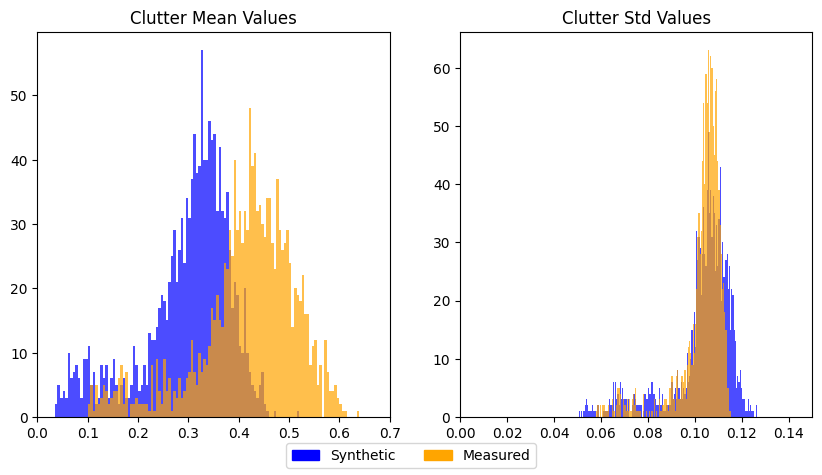

In [17]:
fig = plt.figure(figsize=(10, 5))

color_lst = ['blue', 'orange']
label_lst = ['Synthetic', 'Measured']

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist([val[0] for val in synth_vals], bins = np.arange(0, 1, 0.005), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax1.hist([val[0] for val in meas_vals], bins = np.arange(0, 1, 0.005), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax1.set_xlim(0, 0.7)
ax1.set_title("Clutter Mean Values")

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist([val[1] for val in synth_vals], bins = np.arange(0, 1, 0.0005), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax2.hist([val[1] for val in meas_vals], bins = np.arange(0, 1, 0.0005), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax2.set_xlim(0, 0.15)
ax2.set_title("Clutter Std Values")

legend_handles = [
    mpatches.Patch(color = color, label = ds) for ds, color in zip(label_lst, color_lst)
    ]
fig.legend(handles=legend_handles, loc = "lower center", ncol = 2)
plt.show()